You could use this notebook on [Google Colab](https://colab.research.google.com/) with a GPU Hardware Accelerator runtype.

# Setup


In [2]:
#For some reason pip3 install -r requirements.txt doesn't work on Colab
! pip3 install -r requirements.txt


[notice] A new release of pip available: 22.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Exploratory Data Analysis
A key to the usefulness of this program is understanding the dataset. Knowing the limitations of the current data adds context to the predictions made by the program.

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [4]:
# Connect to Database
con = sqlite3.connect("Data/dataset.sqlite")
main_dataset = pd.read_sql("SELECT * FROM 'dataset_2012-24_new';", con)

print(f"Size of dataset: {len(main_dataset)}")
print(f"Dataset columns: {list(main_dataset.columns)}")
print(main_dataset.loc[0, ['TEAM_NAME', 'Score', 'Home-Team-Win', 'OU', 'OU-Cover', 'Date']])

Size of dataset: 15115
Dataset columns: ['index', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'Date', 'TEAM_NAME.1', 'GP.1', 'W.1', 'L.1', 'W_PCT.1', 'MIN.1', 'FGM.1', 'FGA.1', 'FG_PCT.1', 'FG3M.1', 'FG3A.1', 'FG3_PCT.1', 'FTM.1', 'FTA.1', 'FT_PCT.1', 'OREB.1', 'DREB.1', 'REB.1', 'AST.1', 'TOV.1', 'STL.1', 'BLK.1', 'BLKA.1', 'PF.1', 'PFD.1', 'PTS.1', 'PLUS_MINUS.1', 'GP_RANK.1', 'W_RANK.1', 'L_RANK.1', 'W_PCT_RANK.1', 'MIN_RANK.1', 'FGM_RANK.1', 'FGA_RANK.1', 'FG_PCT_RANK.1', 'FG3M_RANK.1', 'FG3A

In [5]:
# Drop rank for now, it could be useful in the future but it is directly correlated to the statistic itself relative to the rest of the league. 
# I would prefer to normalize team values compared to the average value for that season
main_dataset = main_dataset.drop(['GP_RANK.1', 'W_RANK.1', 'L_RANK.1', 'W_PCT_RANK.1', 'MIN_RANK.1', 'FGM_RANK.1', 'FGA_RANK.1', 'FG_PCT_RANK.1', 'FG3M_RANK.1', 'FG3A_RANK.1', 'FG3_PCT_RANK.1', 'FTM_RANK.1', 'FTA_RANK.1', 'FT_PCT_RANK.1', 'OREB_RANK.1', 'DREB_RANK.1', 'REB_RANK.1', 'AST_RANK.1', 'TOV_RANK.1', 'STL_RANK.1', 'BLK_RANK.1', 'BLKA_RANK.1', 'PF_RANK.1', 'PFD_RANK.1', 'PTS_RANK.1', 'PLUS_MINUS_RANK.1', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK'], axis=1)

In [6]:
print(main_dataset.head(1))

   index        TEAM_NAME   GP    W    L  W_PCT   MIN   FGM   FGA  FG_PCT  \
0      0  New York Knicks  1.0  1.0  0.0    1.0  48.0  36.0  84.0   0.429   

   FG3M  FG3A  FG3_PCT   FTM   FTA  FT_PCT  OREB  DREB   REB   AST   TOV  \
0  19.0  36.0    0.528  13.0  15.0   0.867  13.0  28.0  41.0  27.0  14.0   

    STL  BLK  BLKA    PF   PFD    PTS  PLUS_MINUS        Date  \
0  10.0  0.0   5.0  22.0  18.0  104.0        20.0  2012-11-04   

          TEAM_NAME.1  GP.1  W.1  L.1  W_PCT.1  MIN.1  FGM.1  FGA.1  FG_PCT.1  \
0  Philadelphia 76ers   1.0  1.0  0.0      1.0   48.0   30.0   85.0     0.353   

   FG3M.1  FG3A.1  FG3_PCT.1  FTM.1  FTA.1  FT_PCT.1  OREB.1  DREB.1  REB.1  \
0     7.0    25.0       0.28   17.0   21.0      0.81    14.0    33.0   47.0   

   AST.1  TOV.1  STL.1  BLK.1  BLKA.1  PF.1  PFD.1  PTS.1  PLUS_MINUS.1  \
0   18.0   16.0   13.0   11.0     5.0  14.0   22.0   84.0           9.0   

       Date.1  Score  Home-Team-Win     OU  OU-Cover  Days-Rest-Home  \
0  2012-11-04  1

## Feature Definitions

Each row represents a matchup between two teams.  
TEAM_NAME: Name of the home team. All team statistics count that season's games up to but not including the current game
Days-Rest-Home: The difference in days between the current game and the home team's previous game
GP: games played by the home team
W: wins by the home team
L: losses by the home team
W_PCT: win percentage of the home team
MIN: total minutes  
FGM: Made field goals  
FGA: attempted field goals  
FG_PCT: percentage of field goals made  
FG3M: three point field goals made  
FG3A: three point field goals attempted  
FG3_PCT: percentage of three point field goals made  
FTM: free throws made  
FTA: free throws attempted   
FT_PCT: percentage of free throws made  
OREB: offensive rebounds  
DREB: defensive rebounds  
REB: total rebounds  
AST: assists  
TOV: turnovers  
STL: steals  
BLK: blocks  
BLKA: blocks against  
PF: personal fouls   
PFD: personal fouls drawn  
PTS: total points  
PLUS_MINUS: point differential   
TEAM_NAME.1: Name of the away team. The away team's statistics are represented with a '.1' suffix  
Days-Rest-Away: Days of rest since the away team's previous game
Date(str): Date of the game in format '2012-11-04'  
Home-Team-Win(float): A boolean representing whether the home team won the game  
Score(float): The total score for the game  
OU(float): The predicted over-under value by the sportsbook before the game  
OU-Cover(float): Whether the game's total score exceeded the over under  

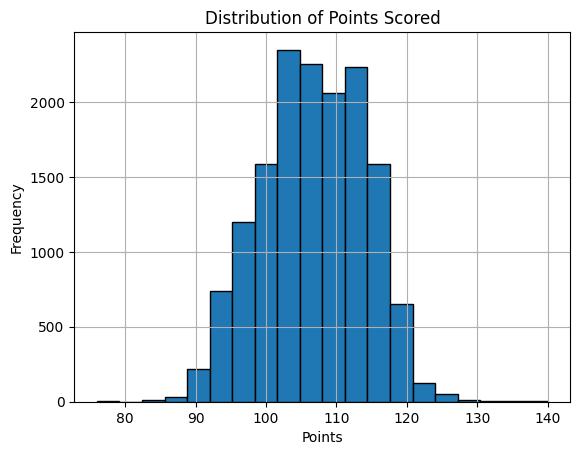

In [7]:
# visualize the points distribution
average_points = main_dataset['PTS']

plt.hist(main_dataset['PTS'], bins=20, edgecolor='black')
plt.title('Distribution of Points Scored')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# TODO:
Where is the over under coming from for these games before gambling was legal?
Clean data: convert to ints, remove highly correlated features, remove ranks
minutes: include to normalize overtime games
